## 1) Importar bibliotecas

In [88]:
import tensorflow as tf
import matplotlib.pyplot as plt
import polars as pl
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

## 2) Ler base de dados

In [89]:
train_df = pl.read_csv(source = "./dados/train_quadratic.csv")

train_df = train_df.with_columns(
    pl.lit(
        np.random.random(
            size = train_df.shape[0]
        )
    ).alias("order")
)

train_df = train_df.sort(
    by = ["order"]
).drop("order")

print(train_df.shape)
train_df.head(2)

(4000, 3)


x,y,class
f64,f64,i64
-3.035409,11.164725,0
2.872553,6.836719,1


### 2.1) Ver quantidade de classes

In [90]:
display(
    train_df.group_by("class").agg(pl.col("class").len().alias("total"))
)

class,total
i64,u32
0,2000
1,2000


### 2.2) Ver distribuição por classe

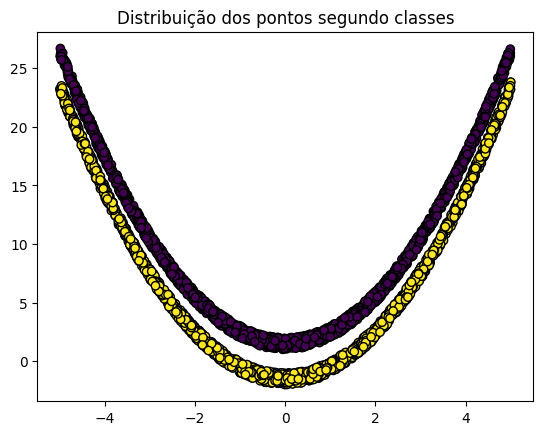

In [91]:
fig, ax = plt.subplots()

ax.scatter(
    x = train_df["x"],
    y = train_df["y"],
    c = train_df["class"],
    edgecolors = "black"
)
ax.set_title("Distribuição dos pontos segundo classes")

plt.show()

### 2.3) Separar dataframe em numpy

In [92]:
X = train_df[["x", "y"]].to_numpy()
y = train_df["class"].to_numpy()

print(X[:5])
print(y[:5])

[[-3.03540889 11.1647254 ]
 [ 2.87255309  6.83671936]
 [-2.63890945  5.49036314]
 [-0.21984837  1.44547418]
 [ 3.00307258  7.92796475]]
[0 1 1 0 1]


## 3) Criar modelo

In [93]:
X.shape

(4000, 2)

### 3.1) Definindo parâmetros

In [94]:
neurons = 5

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape = (2,)),
    tf.keras.layers.Dense(units = 2**neurons, activation = "relu"),
    tf.keras.layers.Dense(units = 2**neurons, activation = "relu"),
    tf.keras.layers.Dense(units = 2, activation = "softmax"),
])

model_optimizer = tf.keras.optimizers.Adam()
model_loss = tf.keras.losses.SparseCategoricalCrossentropy()
model_metrics = tf.keras.metrics.SparseCategoricalAccuracy()

model.compile(
    optimizer = model_optimizer,
    loss = model_loss,
    metrics = [model_metrics],
)

model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 32)             │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,218 (4.76 KB)

 Trainable params: 1,218 (4.76 KB)

 Non-trainable params: 0 (0.00 B)

### 3.2) Configurando <code>early_stopping</code>

In [95]:
model_callback_stopping = tf.keras.callbacks.EarlyStopping(
    min_delta = 1E-2,
    patience = 5,
    verbose = 1
)

### 3.3) Treinando modelo

In [96]:
history = model.fit(
    x = X,
    y = y,
    batch_size = 16,
    validation_split = 0.2,
    shuffle = True,
    epochs = 100,
    callbacks = [model_callback_stopping]
)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.5920 - sparse_categorical_accuracy: 0.6787 - val_loss: 0.4802 - val_sparse_categorical_accuracy: 0.7925
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4298 - sparse_categorical_accuracy: 0.8122 - val_loss: 0.4002 - val_sparse_categorical_accuracy: 0.7837
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3053 - sparse_categorical_accuracy: 0.8944 - val_loss: 0.2758 - val_sparse_categorical_accuracy: 0.9013
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2320 - sparse_categorical_accuracy: 0.9303 - val_loss: 0.2053 - val_sparse_categorical_accuracy: 0.9675
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1992 - sparse_categorical_accuracy: 0.9353 - val_loss: 0.1524 - val_sparse_categorical_accuracy: 0.9812
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1471 - sparse_categorical_accuracy: 0.9697 - val_loss: 0.2277 - val_sparse_categorical_accuracy: 0.918

### 3.4) Avaliando treinamento

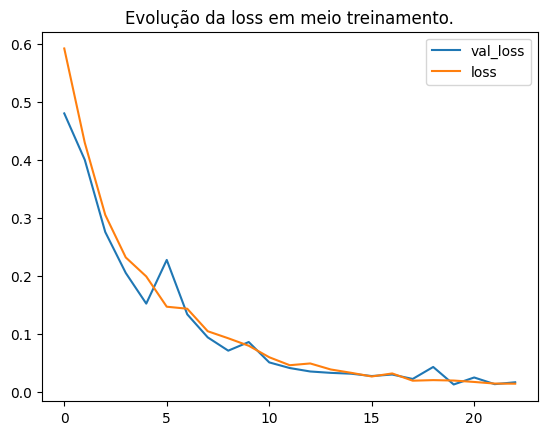

In [97]:
fig, ax = plt.subplots()

ax.plot(
    history.epoch,
    history.history["val_loss"],
    "C0",
    label = "val_loss"
)

ax.plot(
    history.epoch,
    history.history["loss"],
    "C1",
    label = "loss"
)

ax.set_title("Evolução da loss em meio treinamento.")

plt.legend()
plt.show()

### 3.5) Avaliando predição

In [98]:
X_test = pl.read_csv("./dados/test_quadratic.csv")

print(X_test.shape)
X_test.head(2)

(1000, 3)


x,y,class
f64,f64,i64
-0.709694,1.902953,0
1.358063,2.923887,0


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


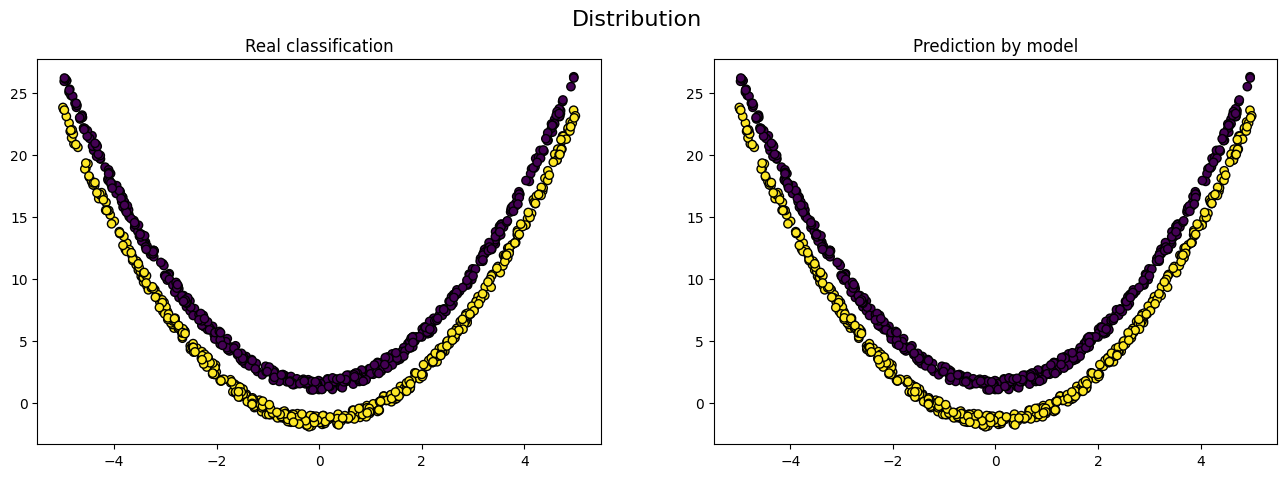

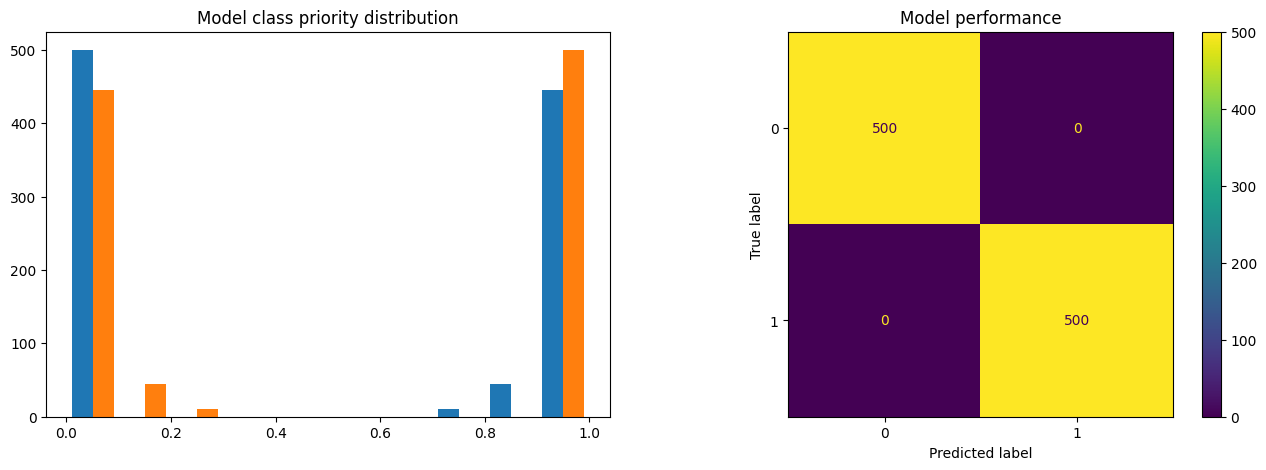

In [102]:
fig, axs = plt.subplots(
    ncols = 2,
    figsize = (16, 5)
)

ax1, ax2 = axs[0], axs[1]
predictions = model.predict(X_test[["x", "y"]].to_numpy())
prediction = predictions.argmax(axis = 1)

ax1.scatter(
    x = X_test["x"],
    y = X_test["y"],
    c = X_test["class"],
    edgecolors = "black",
)

ax2.scatter(
    x = X_test["x"],
    y = X_test["y"],
    c = prediction,
    edgecolors = "black"
)

ax1.set_title("Real classification")
ax2.set_title("Prediction by model")

plt.suptitle("Distribution", fontsize = 16)
plt.show()

fig, axs = plt.subplots(
    ncols = 2,
    figsize = (16, 5)
)

axs[0].hist(
    predictions
)

confusion_matrix_plot = ConfusionMatrixDisplay(
    confusion_matrix = confusion_matrix(y_true= X_test["class"], y_pred=prediction),
)

confusion_matrix_plot.plot(
    ax = axs[1],
    
)
axs[0].set_title("Model class priority distribution")
axs[1].set_title("Model performance")

plt.show()